### Distribution of Electric Range

In [2]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("EV.csv")
df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,JN1AZ0CP5C,Stevens,Colville,WA,99114.0,2012,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,73.0,7.0,153331706,POINT (-117.90454 48.54657),AVISTA CORP,5.306595e+10
1,JTMABABA7P,Yakima,Yakima,WA,98903.0,2023,SUBARU,SOLTERRA,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,15.0,253586308,POINT (-120.71847 46.55029),PACIFICORP,5.307700e+10
2,1N4AZ1CP1J,King,Seattle,WA,98122.0,2018,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,151.0,37.0,333135022,POINT (-122.31009 47.60803),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
3,5UX43EU09S,Kitsap,Poulsbo,WA,98370.0,2025,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,40.0,23.0,267525737,POINT (-122.64681 47.73689),PUGET SOUND ENERGY INC,5.303594e+10
4,3C3CFFGE5F,Thurston,Yelm,WA,98597.0,2015,FIAT,500,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,87.0,2.0,474468501,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC,5.306701e+10


Text(0, 0.5, 'Number of Vehicles')

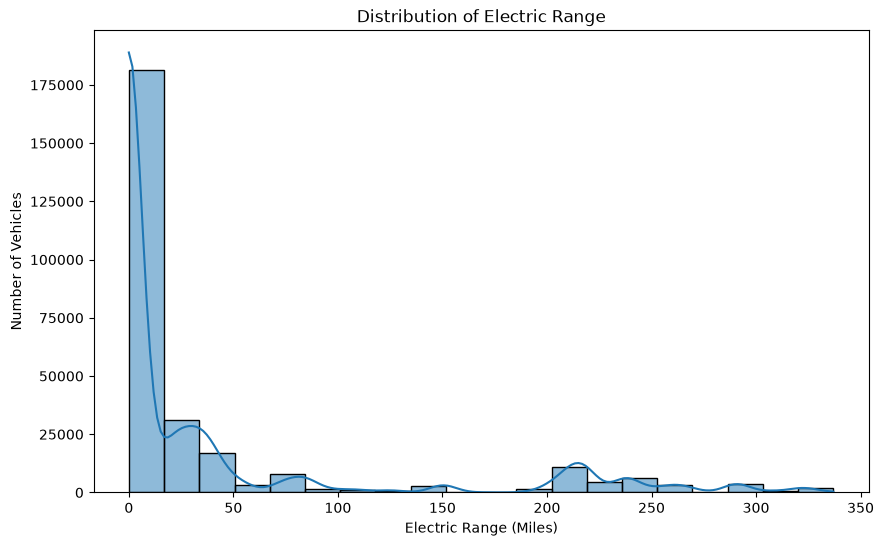

In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(df["Electric Range"], bins=20, kde=True)
plt.title("Distribution of Electric Range")
plt.xlabel("Electric Range (Miles)")
plt.ylabel("Number of Vehicles")

### Boxplot of Electric Range by EV Type

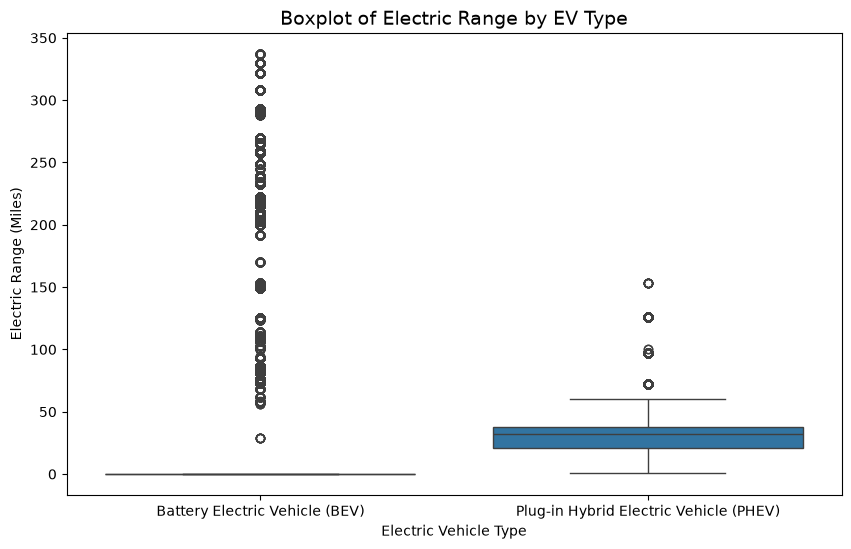

In [5]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="Electric Vehicle Type",y="Electric Range",data=df)
plt.title("Boxplot of Electric Range by EV Type", fontsize=14)
plt.xlabel("Electric Vehicle Type")
plt.ylabel("Electric Range (Miles)")
plt.show()

### Violin plot of Electric Range by Manufacturer

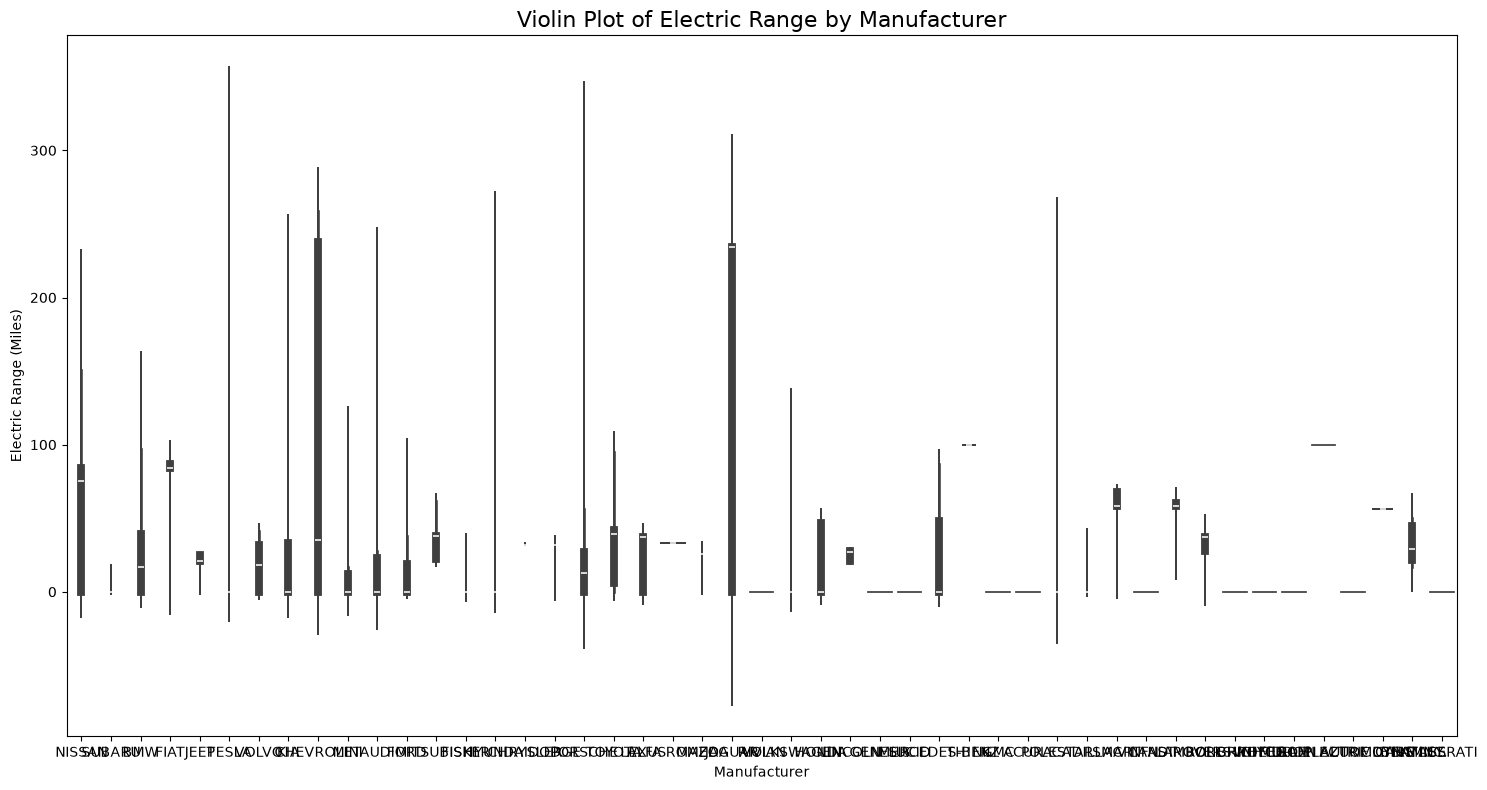

In [6]:
top_makes = df["Make"].value_counts().head(15).index
df_top = df[df["Make"].isin(top_makes)]
plt.figure(figsize=(15, 8))
sns.violinplot(y="Electric Range",x="Make",data=df)
plt.title("Violin Plot of Electric Range by Manufacturer", fontsize=16)
plt.xlabel("Manufacturer")
plt.ylabel("Electric Range (Miles)")
plt.tight_layout()
plt.show()

### Heatmap of missing values

<Axes: >

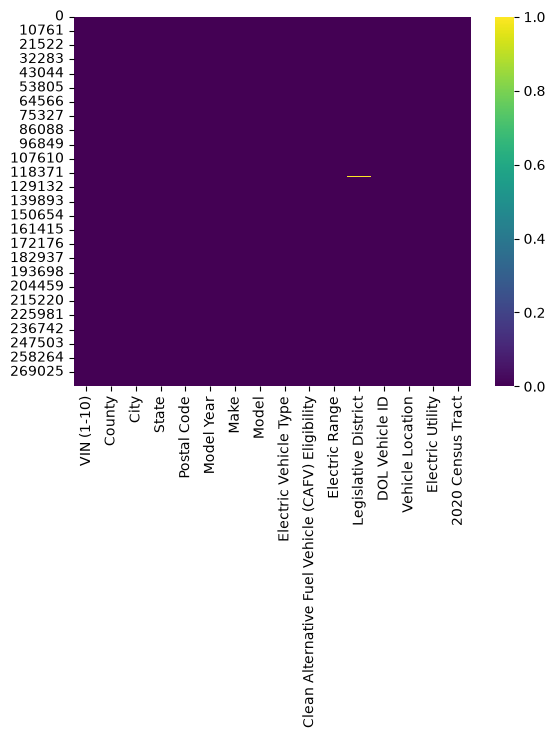

In [7]:
sns.heatmap(df.isnull(),cbar=True,cmap="viridis")

### Correlation heatmap (numeric columns)

<Axes: >

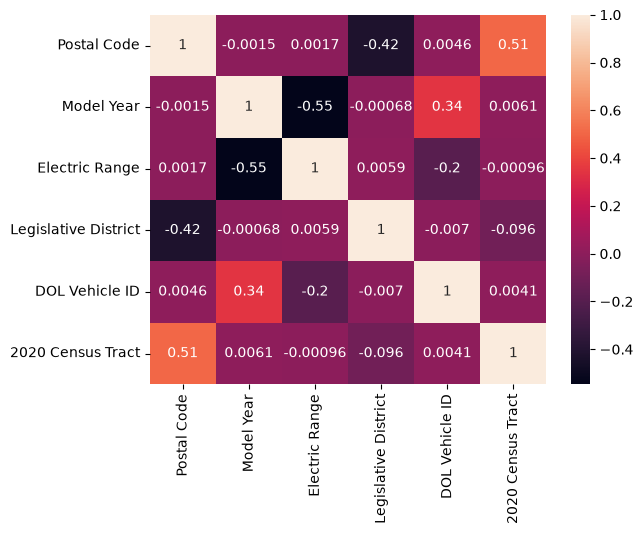

In [11]:
numeric_df = df.select_dtypes(include=["number"])
numeric_df.corr()
sns.heatmap(numeric_df.corr(),annot=True)

### Pairplot of numeric features

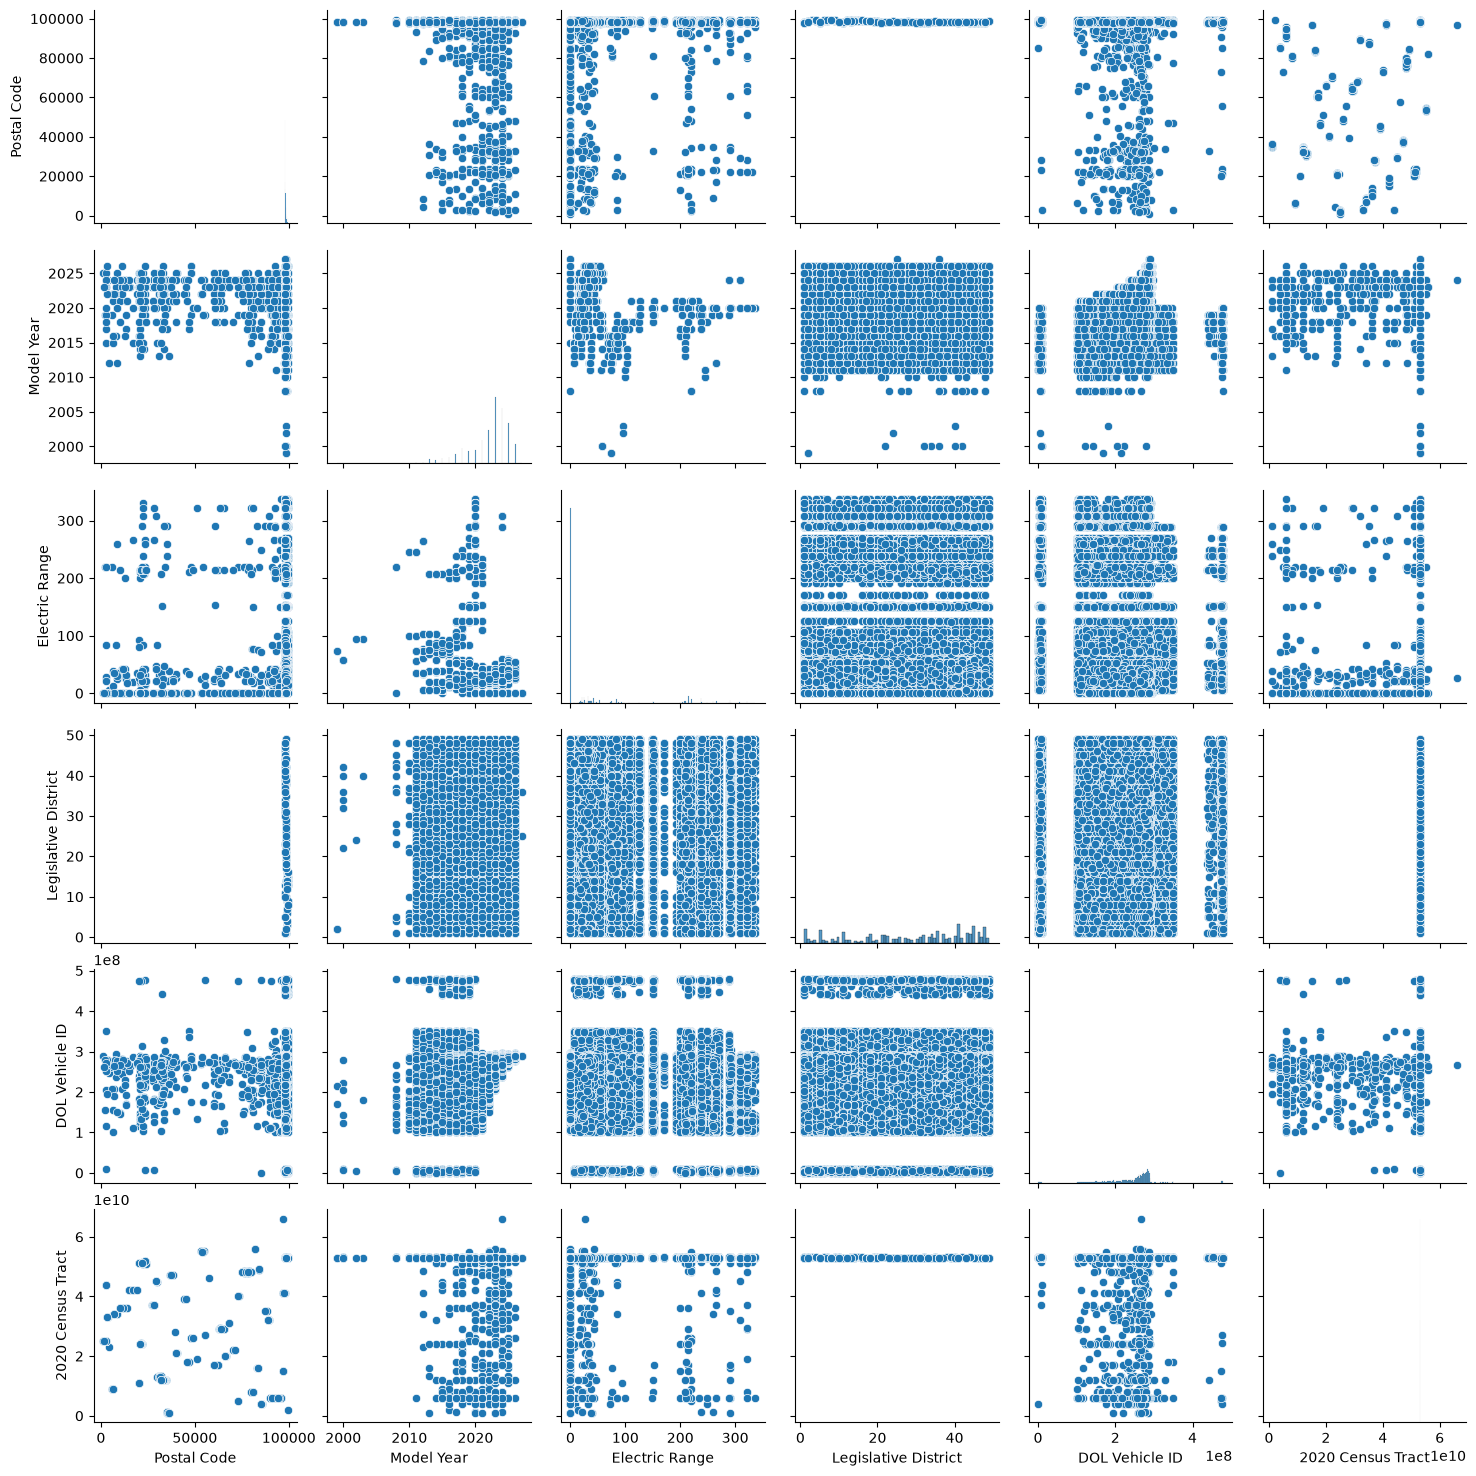

In [13]:
sns.pairplot(numeric_df, diag_kind="hist")

### KDE plot of Electric Range

<Axes: xlabel='Electric Range', ylabel='Density'>

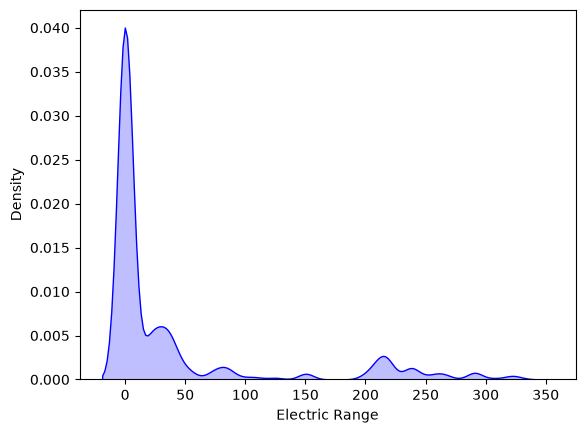

In [16]:
sns.kdeplot(x="Electric Range",data=df,fill=True,color="Blue")

### Which manufacturers produce vehicles with the highest average range?

<Axes: ylabel='Make'>

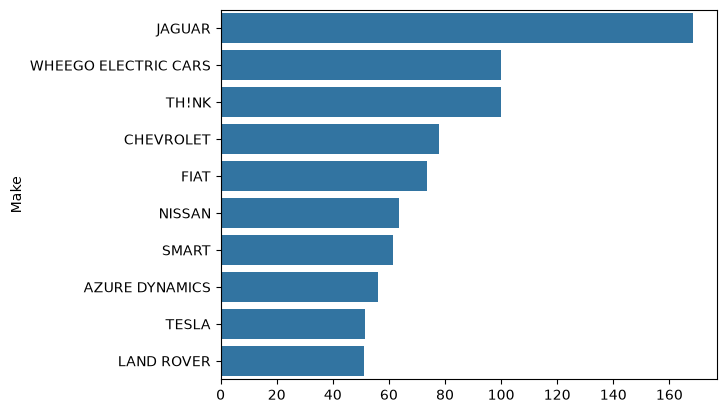

In [23]:
Highest=df.groupby("Make")["Electric Range"].mean().sort_values(ascending=False).head(10)
sns.barplot(y=Highest.index,x=Highest.values)
